# Hourglass Shape


The hourglass shape is used to test the behavior of the margin metrics for 
concave structures. The shape is composed of parts of two circles connected by
parts of two ellipses. For planar metric tests the shape is extruded in the 
z-direction. For Z-metric tests width of the shape at equal intervals of height
are used as the diameter of the circles on the respective plane, resulting in 
the effect of the shape being rotated around the z-axis. 

The Hourglass Equations section below describes the process for generating the 
hourglass shape. The radius of the circles and the distance between them is 
specified, along with some eclipse parameters. The intersection points of the 
circles and ellipses are obtained from the scipy `fsolve` function.  The final 
function is in the debug_tools.py module and returns both the resulting 
hourglass polygon and a dictionary of the hourglass parameters:
- circle_radius: `float`
- left_circle_center: `Tuple[float, float]`
- right_circle_center: `Tuple[float, float]`
- left_circle_extents: `Dict[str, float] ('x_min', 'x_max', 'y_min', 'y_max')`
- right_circle_extents: `Dict[str, float] ('x_min', 'x_max', 'y_min', 'y_max')`
- solved_circle_half_spacing: `float`
- neck_thickness: `float`
- neck_half_width: `float`
- transition_points: `Dict[str, Tuple[float, float]]`
    ('top_right', 'top_left', 'bottom_right', 'bottom_left')
- transition_steepness: `float`
- top_ellipse_center: `Tuple[float, float]`
- bottom_ellipse_center: `Tuple[float, float]`
- top_ellipse_extents: `Dict[str, float] ('x_min', 'x_max', 'y_min', 'y_max')`
- bottom_ellipse_extents: `Dict[str, float] ('x_min', 'x_max', 'y_min', 'y_max')`

The final section of the notebook shows how to use the hourglass shape to test 
the margin metrics. It generates pairs of hourglass shapes and determines the 
margin metrics for each pair. The results are plotted to show how the metrics 
change as the shapes are modified.  The tests include:
- Orthogonal planar margin where the minimum margin is in the concave region 
    of the structure rather than at an outer edge.
- Z margin is in a central location rather than at the top and bottom of the 
    structure

## Setup

### Imports

In [1]:
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

from shapely.geometry import Polygon
from shapely.ops import transform
from shapely.plotting import plot_polygon

import debug_tools
from contour_plotting import plot_ab


INFO:metrics.base:Registered calculator: minimum_margins (ContainmentMarginsCalculator)
INFO:metrics.base:Registered calculator: maximum_margin (MaximumMarginCalculator)
INFO:metrics.base:Registered calculator: minimum_distance (MinimumDistanceCalculator)


### Globals

In [2]:
CM_2_INCH = 0.393701

### Utility functions

In [3]:
# Function to swap X and Y coordinates
def swap_xy(geom):
    return transform(lambda x, y, z=None: (y, x) if z is None else (y, x, z), geom)


## Hourglass Equations

### Equation for an ellipse with a specified height and width


The equation for an ellipse centered at $(h, k)$ with total width $W$ (horizontal axis length) and total height $H$ (vertical axis length) is:

$\frac{(x - h)^2}{\left(\frac{W}{2}\right)^2} + \frac{(y - k)^2}{\left(\frac{H}{2}\right)^2} = 1$

If the ellipse is centered at the origin $(0,0)$, this simplifies to:

$\frac{x^2}{\left(\frac{W}{2}\right)^2} + \frac{y^2}{\left(\frac{H}{2}\right)^2} = 1$

Equivalently, using $a = W/2$ and $b = H/2$:

$\frac{x^2}{a^2} + \frac{y^2}{b^2} = 1$

where $a$ is the semi-major axis length if $W \ge H$ (or semi-minor if $W < H$), and $b$ is the other semi-axis length.


An hourglass shape can be made by combining parts of two circles a specified 
distance apart, with parts of two ellipses a specified distance apart. The 
ellipses are be located between the two circles with their long axis centered 
and perpendicular to a line between the centres of the two circles. 
The shape changes from being delimited by a circle type of equation to an 
ellipse type of equation at a point where the circle and ellipse functions are 
equal and the first derivatives of both functions are also equal.

<img src="../../Images/Box_in_Circle/Hourglass parts.png" 
 alt="Hourglass parts" style="width: 12cm;"><br>

<img src="../../Images/Box_in_Circle/Hourglass Shape.png" alt="Hourglass Shape" style="width: 12cm;">


### Solving for the transition points

#### Starting Parameters:

- `R` Circle radius
- `L` Half distance between circle centers (centers at ±L) Must be > R for non-overlapping circles
- `a` Ellipse horizontal semi-axis (1/2 total width)
- `b` Ellipse vertical semi-axis (1/2 total height)
- `c_input` Initial guess of ellipse center offset

- `enforce_c1 = True` – whether to enforce $c'$ continuity (matching first 
    derivatives) at the transition points. If True, the solver will adjust `c` 
    to ensure the slopes of the circle and ellipse match at the transition 
    points, creating a smooth transition. If False, it sets `c = c_input` and 
    the solver will only find the matching join point.


In [32]:
# Recovered hourglass construction: piecewise circle+ellipse with C1 join
# Component sizes from the sketch
R = 2.5   # circle radius (5 cm diameter)
L = 3.0   # half circle-center spacing (centers at x = ±3)
a = 0.75  # ellipse horizontal semi-axis (1.5 cm total width)
b = 1.25  # ellipse vertical semi-axis (2.5 cm total height)
c_input = 1.45  # requested ellipse center offset

# Set True to enforce C1 continuity (value and first derivative equal)
enforce_c1 = True


In [33]:
# Initial guess
x0_guess = 0.6
y0_guess = np.sqrt(R**2 - (x0_guess - L)**2)   # on circle

if enforce_c1:
    # Unknowns: join x, join y, and adjusted ellipse center offset c
    def c1_system(vars_):
        xj, yj, c_var = vars_
        eq1 = (xj - L) ** 2 + yj ** 2 - R ** 2
        eq2 = (xj ** 2) / (a ** 2) + ((yj - c_var) ** 2) / (b ** 2) - 1.0
        eq3 = (xj - L) / yj - (xj * b ** 2) / ((yj - c_var) * a ** 2)
        return [eq1, eq2, eq3]
    x_join, y_join, c = fsolve(c1_system, [x0_guess, y0_guess, c_input])
else:
    c = c_input

    def join_equations(vars_):
        xj, yj = vars_
        eq1 = (xj - L) ** 2 + yj ** 2 - R ** 2
        eq2 = (xj ** 2) / (a ** 2) + ((yj - c) ** 2) / (b ** 2) - 1.0
        return [eq1, eq2]

    x_join, y_join = fsolve(join_equations, [x0_guess, y0_guess])

def y_circle_top_right(x):
    return np.sqrt(np.maximum(0.0, R ** 2 - (x - L) ** 2))


def y_circle_top_left(x):
    return np.sqrt(np.maximum(0.0, R ** 2 - (x + L) ** 2))


def y_circle_bot_right(x):
    return -y_circle_top_right(x)


def y_circle_bot_left(x):
    return -y_circle_top_left(x)


def y_ellipse_top_inner(x):
    return c - b * np.sqrt(np.maximum(0.0, 1.0 - (x ** 2) / (a ** 2)))


def y_ellipse_bottom_inner(x):
    return -c + b * np.sqrt(np.maximum(0.0, 1.0 - (x ** 2) / (a ** 2)))

# Slope continuity report at the join
m_circle = -(x_join - L) / y_join
m_ellipse = -((b ** 2) * x_join) / ((y_join - c) * (a ** 2))
print(f'Input c = {c_input:.3f}')
print(f'Used c  = {c:.3f}')
# Transition Point guess and final values
print(f'\nInitial guess: x = ±{x0_guess:.3f}, y = ±{y0_guess:.3f}')
print(f'Join point: x = ±{x_join:.3f}, y = ±{y_join:.3f}')
# Slope continuity report at the join
print('\nSlopes at join point:')
print(f'Slope(circle) = {m_circle:.3f}')
print(f'Slope(ellipse) = {m_ellipse:.3f}')
print(f'Slope difference = {abs(m_circle - m_ellipse):.3e}')


Input c = 1.450
Used c  = 1.477

Initial guess: x = ±0.600, y = ±0.700
Join point: x = ±0.645, y = ±0.839

Slopes at join point:
Slope(circle) = 2.808
Slope(ellipse) = 2.808
Slope difference = 1.641e-11


### Plot the resulting shape

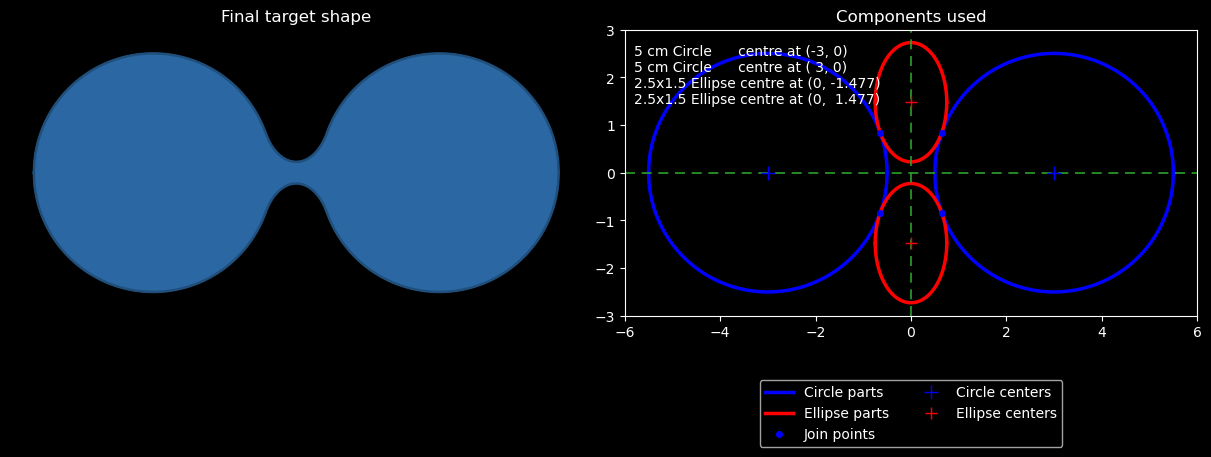

In [37]:
# Top boundary: left circle -> top inner ellipse -> right circle
x_top_left = np.linspace(-L - R, -x_join, 500)
y_top_left = y_circle_top_left(x_top_left)

x_top_mid = np.linspace(-x_join, x_join, 500)
y_top_mid = y_ellipse_top_inner(x_top_mid)

x_top_right = np.linspace(x_join, L + R, 500)
y_top_right = y_circle_top_right(x_top_right)

# Bottom boundary in reverse-x order for polygon closure
x_bot_right = np.linspace(L + R, x_join, 500)
y_bot_right = y_circle_bot_right(x_bot_right)

x_bot_mid = np.linspace(x_join, -x_join, 500)
y_bot_mid = y_ellipse_bottom_inner(x_bot_mid)

x_bot_left = np.linspace(-x_join, -L - R, 500)
y_bot_left = y_circle_bot_left(x_bot_left)

# Closed polygon of final shape
x_poly = np.concatenate([
    x_top_left, x_top_mid, x_top_right,
    x_bot_right, x_bot_mid, x_bot_left,
    ])
y_poly = np.concatenate([
    y_top_left, y_top_mid, y_top_right,
    y_bot_right, y_bot_mid, y_bot_left,
    ])

# Component curves for the right panel
x_full_c1 = np.linspace(-L - R, -L + R, 700)
y_full_c1_top = y_circle_top_left(x_full_c1)
y_full_c1_bot = y_circle_bot_left(x_full_c1)

x_full_c2 = np.linspace(L - R, L + R, 700)
y_full_c2_top = y_circle_top_right(x_full_c2)
y_full_c2_bot = y_circle_bot_right(x_full_c2)

x_ell = np.linspace(-a, a, 700)
y_ell_top_up = c + b * np.sqrt(np.maximum(0.0, 1.0 - (x_ell ** 2) / (a ** 2)))
y_ell_top_dn = c - b * np.sqrt(np.maximum(0.0, 1.0 - (x_ell ** 2) / (a ** 2)))
y_ell_bot_up = -c + b * np.sqrt(np.maximum(0.0, 1.0 - (x_ell ** 2) / (a ** 2)))
y_ell_bot_dn = -c - b * np.sqrt(np.maximum(0.0, 1.0 - (x_ell ** 2) / (a ** 2)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Left panel: final target shape
ax = axes[0]
ax.fill(x_poly, y_poly, color='#2b67a3')
ax.plot(x_poly, y_poly, color='#1f4f7a', linewidth=1.8)
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-6, 6)
ax.set_ylim(-3, 3)
ax.set_facecolor('#e8e8e8')
ax.axis('off')
ax.set_title('Final target shape')

# Right panel: component circles and ellipses
ax = axes[1]
ax.plot(x_full_c1, y_full_c1_top, color='blue', linewidth=2.5, label='Circle parts')
ax.plot(x_full_c1, y_full_c1_bot, color='blue', linewidth=2.5)
ax.plot(x_full_c2, y_full_c2_top, color='blue', linewidth=2.5)
ax.plot(x_full_c2, y_full_c2_bot, color='blue', linewidth=2.5)
ax.plot(x_ell, y_ell_top_up, color='red', linewidth=2.5, label='Ellipse parts')
ax.plot(x_ell, y_ell_top_dn, color='red', linewidth=2.5)
ax.plot(x_ell, y_ell_bot_up, color='red', linewidth=2.5)
ax.plot(x_ell, y_ell_bot_dn, color='red', linewidth=2.5)
ax.axhline(0.0, color='#2ca02c', linestyle=(0, (6, 4)), linewidth=1.2)
ax.axvline(0.0, color='#2ca02c', linestyle=(0, (6, 4)), linewidth=1.2)
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-6, 6)
ax.set_ylim(-3, 3)
ax.set_title('Components used')
ax.grid(False)

component_text = [
    '5 cm Circle      centre at (-3, 0)',
    '5 cm Circle      centre at ( 3, 0)',
    f'2.5x1.5 Ellipse centre at (0, {-c:.3f})',
    f'2.5x1.5 Ellipse centre at (0,  {c:.3f})',
]
ax.text(-5.8, 2.7, '\n'.join(component_text), va='top', fontsize=10)

# Join markers
ax.plot([x_join, -x_join], [y_join, y_join], 'bo', ms=4, label='Join points')
ax.plot([x_join, -x_join], [-y_join, -y_join], 'bo', ms=4)
# Add centers for reference
plt.plot([-L, L], [0, 0], 'b+', markersize=10, label='Circle centers')
plt.plot([0, 0], [c, -c], 'r+', markersize=8, label='Ellipse centers')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=True)
plt.show()

#### Plot description

When you run the code with the given example parameters:
- $R=2.5$ - circle radius, 
- $L=3.0$, - half circle-center spacing
- $a=0.75$, - ellipse horizontal semi-axis (1.5 cm total width)
- $b=1.25$, - ellipse vertical semi-axis (2.5 cm total height)
- $c \approx 1.48$ - ellipse center height (automatically adjusted to enforce 
    $C'$ continuity at the transition point)

The result is:
- Two **blue circular arcs** on the left and right, each belonging to circles of 
    radius 2.5 centered at $(-3.0,0)$ and $(3.0,0)$.
- Two **red elliptical arcs** connecting them at the top nd bottom, belonging to 
    ellipses centered at $(0,\approx 1.48)$ and $(0,\approx -1.48)$ (computed 
    automatically) with vertical semi-axis of $1.5$ and horizontal semi-axis of 
    $0.75$ .
- **Cyan dots** mark the join points $(\pm x_0, \pm y_0)$ where the circle and 
    ellipse meet with matching position and slope ($C'$ continuity). For these 
    parameters, $x_0 \approx 0.66$, $y_0 \approx 0.84$.
- The shape is symmetric about both axes, so the left and right arcs are
    mirror images, and the top and bottom arcs are mirror images. The 
    transition points are located symmetrically on either side of the center
    line.


## Reusable hourglass polygon for testing

This step uses `make_hourglass_polygon` from `debug_tools.py` and plots the output polygon. 
Adjust parameters to control circle size, neck thickness, and transition steepness.

Hourglass geometry report
  circle_radius: 2.5
  neck_thickness: 0.4
  transition_steepness: 1.25
  neck_half_width: 0.75
  solved_circle_half_spacing: 3.009475525283939
  left_circle_center: (-3.009475525283939, 0.0)
  right_circle_center: (3.009475525283939, 0.0)
  left_circle_extents: {'x_min': -5.509475525283939, 'x_max': -0.5094755252839391, 'y_min': -2.5, 'y_max': 2.5}
  right_circle_extents: {'x_min': 0.5094755252839391, 'x_max': 5.509475525283939, 'y_min': -2.5, 'y_max': 2.5}
  top_ellipse_center: (0.0, 1.45)
  bottom_ellipse_center: (0.0, -1.45)
  top_ellipse_extents: {'x_min': -0.75, 'x_max': 0.75, 'y_min': 0.19999999999999996, 'y_max': 2.7}
  bottom_ellipse_extents: {'x_min': -0.75, 'x_max': 0.75, 'y_min': -2.7, 'y_max': -0.19999999999999996}
  transition_points: {'top_right': (0.6486124235248355, 0.8223900626834496), 'top_left': (-0.6486124235248355, 0.8223900626834496), 'bottom_right': (0.6486124235248355, -0.8223900626834496), 'bottom_left': (-0.6486124235248355, -0.82239

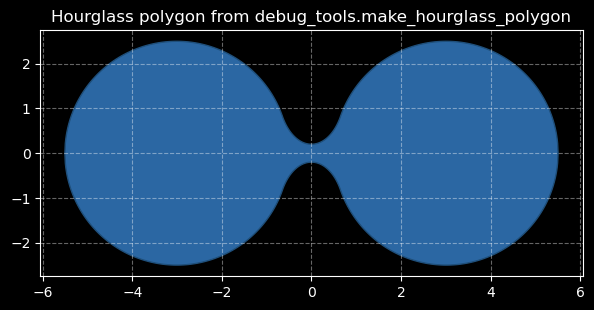

In [9]:
hourglass_poly, geometry = debug_tools.make_hourglass_polygon(
    circle_radius=2.5,
    neck_thickness=0.40,
    transition_steepness=1.25,
    neck_half_width=0.75,
    offset_x=0.0,
    offset_y=0.0,
    report_points=True,
    )

print(f'Polygon area: {hourglass_poly.area:.4f}')
print(f'Polygon bounds: {hourglass_poly.bounds}')

fig, ax = plt.subplots(figsize=(7, 3.8))
plot_polygon(hourglass_poly, ax=ax, add_points=False, facecolor='#2b67a3', edgecolor='#1f4f7a')
ax.set_aspect('equal', adjustable='box')
ax.set_title('Hourglass polygon from debug_tools.make_hourglass_polygon')
ax.grid(True, linestyle='--', alpha=0.4)
plt.show()

## Hourglass Shapes for testing metrics
- Want Z margin in a central location
- This means the gap between structures at the neck should be smaller than the 
    gap at the top and bottom


    Z margin is in a central location


    hourglass_poly = debug_tools.make_hourglass_polygon(
    circle_radius=2.5,
    neck_thickness=0.40,
    transition_steepness=1.25,
    neck_half_width=0.75,
    offset_x=0.0,
    offset_y=0.0,
    report_points=True,
    )

In [10]:
hourglass_poly1, geometry1 = debug_tools.make_hourglass_polygon(
    circle_radius=2.5,
    neck_thickness=1.0,
    transition_steepness=1.25,
    neck_half_width=1.0,
    offset_x=0.0,
    offset_y=0.0,
    report_points=True,
    )
hourglass_poly2, geometry2 = debug_tools.make_hourglass_polygon(
    circle_radius=2,
    neck_thickness=0.50,
    transition_steepness=1.25,
    neck_half_width=1.0,
    offset_x=0.0,
    offset_y=0.0,
    report_points=True,
    )

hourglass_poly1 = swap_xy(hourglass_poly1)
hourglass_poly2 = swap_xy(hourglass_poly2)

Hourglass geometry report
  circle_radius: 2.5
  neck_thickness: 1.0
  transition_steepness: 1.25
  neck_half_width: 1.0
  solved_circle_half_spacing: 3.0991634539023485
  left_circle_center: (-3.0991634539023485, 0.0)
  right_circle_center: (3.0991634539023485, 0.0)
  left_circle_extents: {'x_min': -5.5991634539023485, 'x_max': -0.5991634539023485, 'y_min': -2.5, 'y_max': 2.5}
  right_circle_extents: {'x_min': 0.5991634539023485, 'x_max': 5.5991634539023485, 'y_min': -2.5, 'y_max': 2.5}
  top_ellipse_center: (0.0, 1.75)
  bottom_ellipse_center: (0.0, -1.75)
  top_ellipse_extents: {'x_min': -1.0, 'x_max': 1.0, 'y_min': 0.5, 'y_max': 3.0}
  bottom_ellipse_extents: {'x_min': -1.0, 'x_max': 1.0, 'y_min': -3.0, 'y_max': -0.5}
  transition_points: {'top_right': (0.8532541841098785, 1.0981309356346731), 'top_left': (-0.8532541841098785, 1.0981309356346731), 'bottom_right': (0.8532541841098785, -1.0981309356346731), 'bottom_left': (-0.8532541841098785, -1.0981309356346731)}
Hourglass geometry

In [11]:
def plot_points(ax, join_pts, style='co', ms=4):
    join_pts_swapped = [(y, x) for x, y in join_pts]

    join_arr = np.array(join_pts_swapped)
    ax.plot(join_arr[:, 0], join_arr[:, 1], style, ms=ms)

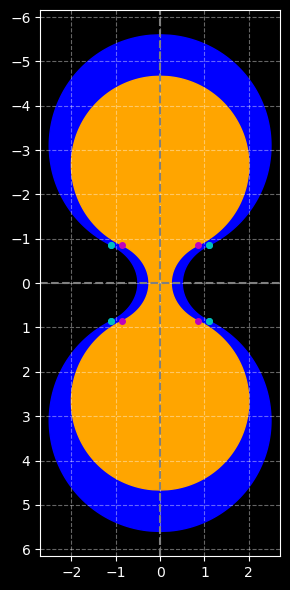

In [12]:
# Create figure and plot
fig, ax = plt.subplots(1, 1, figsize=(3, 6))
plot_ab(hourglass_poly1, hourglass_poly2,
        add_axis=True, axes=ax)

# Extract and swap to match swap_xy(hourglass_poly1/hourglass_poly2)
# Join markers
marker_labels = ['top_right', 'top_left', 'bottom_right', 'bottom_left']
join_pts = [geometry1['transition_points'][label] for label in marker_labels]
plot_points(ax, join_pts)

# Extract and swap to match swap_xy(hourglass_poly1/hourglass_poly2)
# Join markers
marker_labels = ['top_right', 'top_left', 'bottom_right', 'bottom_left']
join_pts = [geometry1['transition_points'][label] for label in marker_labels]
plot_points(ax, join_pts, style='co', ms=4)
join_pts = [geometry2['transition_points'][label] for label in marker_labels]
plot_points(ax, join_pts, style='mo', ms=4)

ax.set_axis_on()
ax.set_xticks([-2.0, -1.0, 0.0, 1.0, 2.0])
ax.set_yticks([-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6])

ax.grid(True, linestyle='--', alpha=0.4)
ax.set()
plt.tight_layout()
plt.show()

- Orthogonal planar margin is at the transition_points

# TEMP

{'bottom_left': (-0.8591437379678319, -0.8603320716103273),
 'bottom_right': (0.8591437379678319, -0.8603320716103273),
 'top_left': (-0.8591437379678319, 0.8603320716103273),
 'top_right': (0.8591437379678319, 0.8603320716103273)}
Join point: x0 = 0.5168, y0 = 0.4101
Ellipse a (horizontal semi-axis) = -0.5306


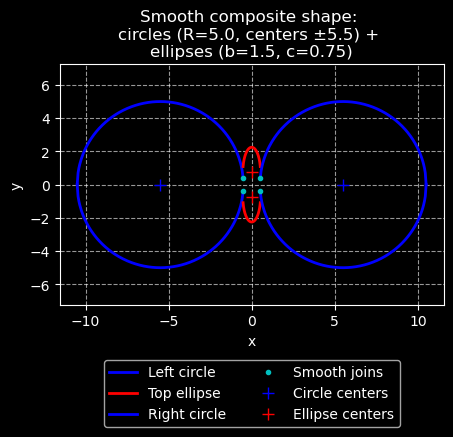

In [26]:
pprint(geometry2['transition_points'])# -------- Parameters --------
R = 5.0          # circle radius
L = 5.5          # half distance between circle centers (centers at ±L) Must be > R for non-overlapping circles
b_ell = 1.5      # vertical semi-axis of ellipse (b)
c_ell = 0.75     # y-coordinate of ellipse center

# -------- Solve for join point (x0, y0) and ellipse horizontal semi-axis a --------
def equations(vars):
    x0, y0, a = vars
    eq1 = (x0 - L)**2 + y0**2 - R**2
    eq2 = (x0**2)/(a**2) + ((y0 - c_ell)**2)/(b_ell**2) - 1.0
    # derivative matching: (x0-L)/y0 = (x0 * b_ell**2) / ((y0 - c_ell) * a**2)
    eq3 = (x0 - L) * (y0 - c_ell) * a**2 - (x0 * b_ell**2 * y0)
    return [eq1, eq2, eq3]

# Initial guess
x0_guess = 2.0
y0_guess = np.sqrt(R**2 - (x0_guess - L)**2)   # on circle
a_guess = 4.0
sol = fsolve(equations, [x0_guess, y0_guess, a_guess])
x0, y0, a = sol
print(f"Join point: x0 = {x0:.4f}, y0 = {y0:.4f}")
print(f"Ellipse a (horizontal semi-axis) = {a:.4f}")

# -------- Build the curve --------
# x ranges:
# Left circle: from -L-R to -x0
# Top ellipse: from -x0 to x0
# Right circle: from x0 to L+R

x_left = np.linspace(-L-R, -x0, 200)
y_left = np.sqrt(R**2 - (x_left + L)**2)

x_ell = np.linspace(-x0, x0, 300)
y_ell = c_ell + b_ell * np.sqrt(1 - (x_ell**2)/(a**2))

x_right = np.linspace(x0, L+R, 200)
y_right = np.sqrt(R**2 - (x_right - L)**2)

# Bottom half (symmetric)
x_left_b = np.linspace(-L-R, -x0, 200)
y_left_b = -np.sqrt(R**2 - (x_left_b + L)**2)

x_ell_b = np.linspace(-x0, x0, 300)
y_ell_b = -(c_ell + b_ell * np.sqrt(1 - (x_ell_b**2)/(a**2)))

x_right_b = np.linspace(x0, L+R, 200)
y_right_b = -np.sqrt(R**2 - (x_right_b - L)**2)

# -------- Plot --------
plt.figure(figsize=(12*CM_2_INCH, 12*CM_2_INCH))
plt.plot(x_left, y_left, 'b-', linewidth=2, label='Left circle')
plt.plot(x_ell, y_ell, 'r-', linewidth=2, label='Top ellipse')
plt.plot(x_right, y_right, 'b-', linewidth=2, label='Right circle')
plt.plot(x_left_b, y_left_b, 'b-', linewidth=2)
plt.plot(x_ell_b, y_ell_b, 'r-', linewidth=2)
plt.plot(x_right_b, y_right_b, 'b-', linewidth=2)

# Mark the join points
plt.plot([-x0, x0], [y0, y0], 'co', markersize=3, label='Smooth joins')
plt.plot([-x0, x0], [-y0, -y0], 'co', markersize=3)

# Add centers for reference
plt.plot([-L, L], [0, 0], 'b+', markersize=8, label='Circle centers')
plt.plot([0, 0], [c_ell, -c_ell], 'r+', markersize=8, label='Ellipse centers')

plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.title(f"Smooth composite shape: \ncircles (R={R}, centers ±{L}) + \nellipses (b={b_ell}, c={c_ell})")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=True)
plt.tight_layout()
plt.show()